In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler

In [2]:
# 设置随机种子以保证结果可复现
np.random.seed(42)
from matplotlib import rcParams
# 配置 matplotlib 使用中文字体
def config_fonts():
    try:
        # 尝试多种常用中文字体，优先使用挂载的字体
        # SimHei: Windows标准/Docker挂载
        # Heiti TC: Mac标准
        fonts = ['SimHei', 'Heiti TC', 'WenQuanYi Micro Hei', 'DejaVu Sans']
        rcParams['font.sans-serif'] = fonts
        rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
    except:
        pass

config_fonts()    

总数据点数: 850


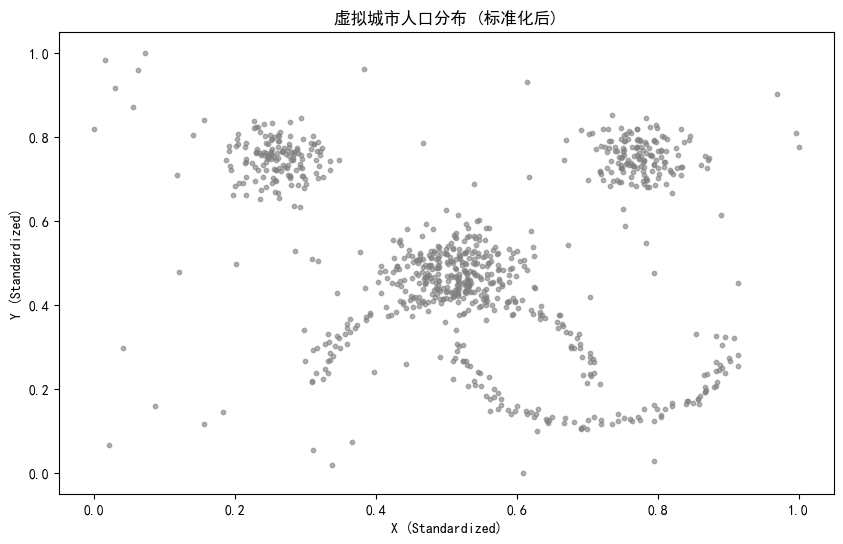

In [3]:
# 1. 城市中心 (高密度，团状)
from sklearn.preprocessing import MinMaxScaler


centers = [[0, 0], [2, 2], [-2, 2]]
X_city, _ = make_blobs(n_samples=[300,150,150],centers=centers,cluster_std=[0.4,0.3,0.3],random_state=42)
# 2. 河流/公路 (非凸形状，弯曲)
X_river,_ = make_moons(n_samples=200,noise=0.05,random_state=42)
X_river = X_river * 1.5 + np.array([0,-2]) # # 调整位置和大小
# 3. 稀疏郊区/噪声 (均匀分布)
n_noise = 50
X_noise = np.random.uniform(low=-4, high=4, size=(n_noise, 2))
# 合并所有数据
X = np.vstack([X_city,X_river,X_noise])
print(f"总数据点数: {X.shape[0]}")
# 数据标准化 (对于基于距离的算法至关重要)
X_scaled = MinMaxScaler().fit_transform(X)

# 可视化原始数据
plt.figure(figsize=(10,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1],s=10,c='gray',alpha=0.6)
plt.title("虚拟城市人口分布 (标准化后)")
plt.xlabel("X (Standardized)")
plt.ylabel("Y (Standardized)")
plt.show()


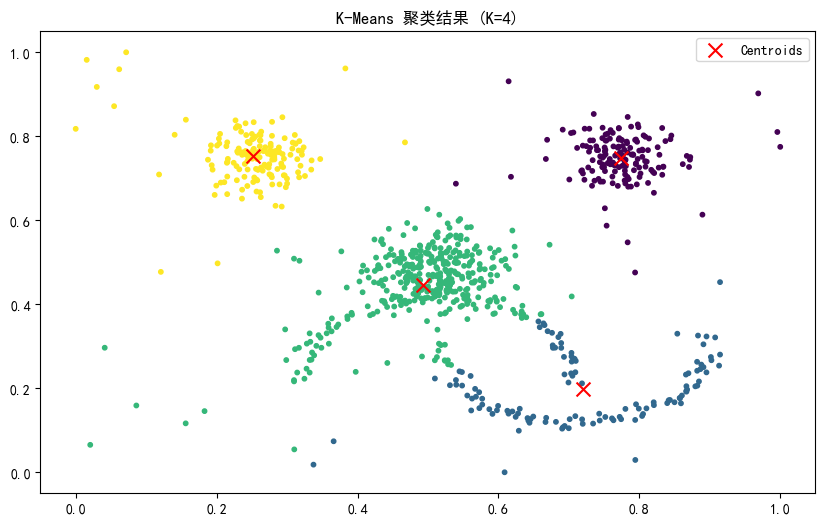

In [6]:
# K-Means 聚类效果
kmeans = KMeans(n_clusters=4,random_state=42)
y_km = kmeans.fit_predict(X_scaled)
plt.figure(figsize=(10,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=y_km,s=10,cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='red',s=100,marker='x',label='Centroids')
plt.title("K-Means 聚类结果 (K=4)")
plt.legend()
plt.show()

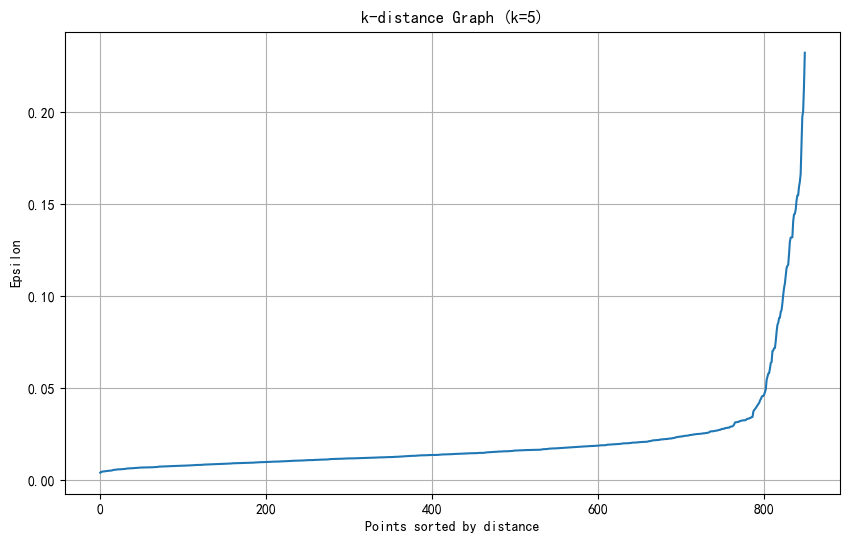

In [8]:
# DBSCAN 参数选择 (k-distance graph)
from sklearn.neighbors import NearestNeighbors

# 计算每个点到其第 k 个最近邻居的距离
k=5
knn = NearestNeighbors(n_neighbors=k)
knn_fitted = knn.fit(X_scaled)
distance,indices = knn_fitted.kneighbors(X_scaled)
# 排序距离
distance = np.sort(distance[:,k-1],axis=0)
plt.figure(figsize=(10,6))
plt.plot(distance)
plt.title("k-distance Graph (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("Epsilon")
plt.grid(True) # 显示网格
plt.show()

发现的簇数量: 3
噪声点数量: 42


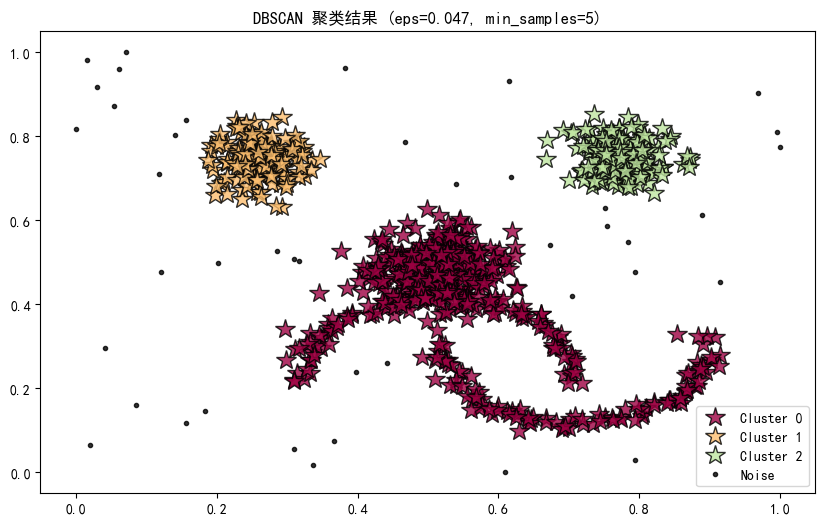

In [15]:
# DBSCAN 聚类效果
dbs = DBSCAN(eps=0.047,min_samples=5)
# 训练DBScan
dbs.fit(X_scaled)
y_db = dbs.labels_

# 统计结果
n_clusters_ = len(set(y_db))-(1 if -1 in y_db else 0)
n_noise_ = list(y_db).count(-1)
print(f"发现的簇数量: {n_clusters_}")
print(f"噪声点数量: {n_noise_}")

# 可视化
plt.figure(figsize=(10,6))
unique_lbls = set(y_db) # 用set来去重
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_lbls))]

for k,col in zip(unique_lbls,colors):
    if k == -1:  # -1表示是噪声
        # 黑色用于表示噪声
        col = [0, 0, 0, 1]
        label = "Noise"
        marker = '.'
        size=7
    else:
        label = f"Cluster {k}"    
        # marker = '^'
        marker = '*'
        size = 15

    class_member_mask = (y_db==k)    
    xy = X_scaled[class_member_mask]
    plt.plot(xy[:,0],xy[:,1],marker,markerfacecolor=tuple(col),markeredgecolor='k', markersize=size if k != -1 else 6,alpha=0.8,label=label)

plt.title(f"DBSCAN 聚类结果 (eps=0.047, min_samples=5)")
plt.legend()
plt.show()
